<a href="https://colab.research.google.com/github/hritikpatel230371-ux/ML-LAB/blob/main/Copy_of_CI1_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Move to the place where data resides**

In [10]:
%cd /content/drive/MyDrive/ML

/content/drive/MyDrive/ML


In [11]:
!ls

covid_dataset.zip


**3. Unziping the dataset**

In [12]:
!pip install unzip

  Preparing metadata (setup.py) ... done
  Created wheel for unzip: filename=unzip-1.0.0-py3-none-any.whl size=1281 sha256=5a42062328e4a64524ea6770c275d5da7f620f8306ef0afd02138eb0af3d9b3c
  Stored in directory: /root/.cache/pip/wheels/fb/5b/81/0f3e1e533b52883f88ab978178c15627a4fce4c13f74911dce
Successfully built unzip


In [13]:
!unzip covid_dataset.zip

Archive:  covid_dataset.zip
   creating: covid_dataset/
   creating: covid_dataset/COVID/
  inflating: covid_dataset/COVID/COVID-1.png  
  inflating: covid_dataset/COVID/COVID-10.png  
  inflating: covid_dataset/COVID/COVID-11.png  
  inflating: covid_dataset/COVID/COVID-12.png  
  inflating: covid_dataset/COVID/COVID-13.png  
  inflating: covid_dataset/COVID/COVID-14.png  
  inflating: covid_dataset/COVID/COVID-15.png  
  inflating: covid_dataset/COVID/COVID-16.png  
  inflating: covid_dataset/COVID/COVID-17.png  
  inflating: covid_dataset/COVID/COVID-18.png  
  inflating: covid_dataset/COVID/COVID-19.png  
  inflating: covid_dataset/COVID/COVID-2.png  
  inflating: covid_dataset/COVID/COVID-20.png  
  inflating: covid_dataset/COVID/COVID-21.png  
  inflating: covid_dataset/COVID/COVID-22.png  
  inflating: covid_dataset/COVID/COVID-23.png  
  inflating: covid_dataset/COVID/COVID-24.png  
  inflating: covid_dataset/COVID/COVID-25.png  
  inflating: covid_dataset/COVID/COVID-26.png  


**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [14]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [20]:
import splitfolders
import os

# Get the current working directory
current_dir = os.getcwd()

# Define absolute paths for input and output
input_path = os.path.join(current_dir, "covid_dataset")
output_path = os.path.join(current_dir, "split")

# Split the dataset using absolute paths
splitfolders.ratio(input_path, output=output_path, seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [00:01, 75.26 files/s]


**6. Loading the dataset with normalization in batches**

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Get the current working directory to form absolute paths
current_working_directory = os.getcwd()
base_split_path = os.path.join(current_working_directory, 'split')

# Check if the training directory exists
train_dir = os.path.join(base_split_path, 'train')
if not os.path.exists(train_dir):
    raise FileNotFoundError(
        f"Error: The training directory '{train_dir}' does not exist. "
        "Please ensure that the data splitting step (Cell 8xXGHVOIlheA) was executed successfully "
        "and created the 'split' directory with 'train', 'val', and 'test' subdirectories."
    )

# Normalize training and validation data in the range of 0 to 1
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Read the training sample and set the batch size
train_generator = train_datagen.flow_from_directory(
        train_dir, # Use absolute path
        target_size=(224, 224), # Changed from 128, 128 to 224, 224
        batch_size=8,
        seed=100,
        class_mode='categorical')

# Read Validation data from directory and define target size with batch size
validation_generator = validation_datagen.flow_from_directory(
        os.path.join(base_split_path, 'val'), # Use absolute path
        target_size=(224, 224), # Changed from 128, 128 to 224, 224
        batch_size=8,
        class_mode='categorical',
        seed=1000,
        shuffle=False)

test_generator = test_datagen.flow_from_directory(
        os.path.join(base_split_path, 'test'), # Use absolute path
        target_size=(224, 224), # Changed from 128, 128 to 224, 224
        batch_size=8,
        seed=500,
        class_mode='categorical',
        shuffle=False)

Found 120 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


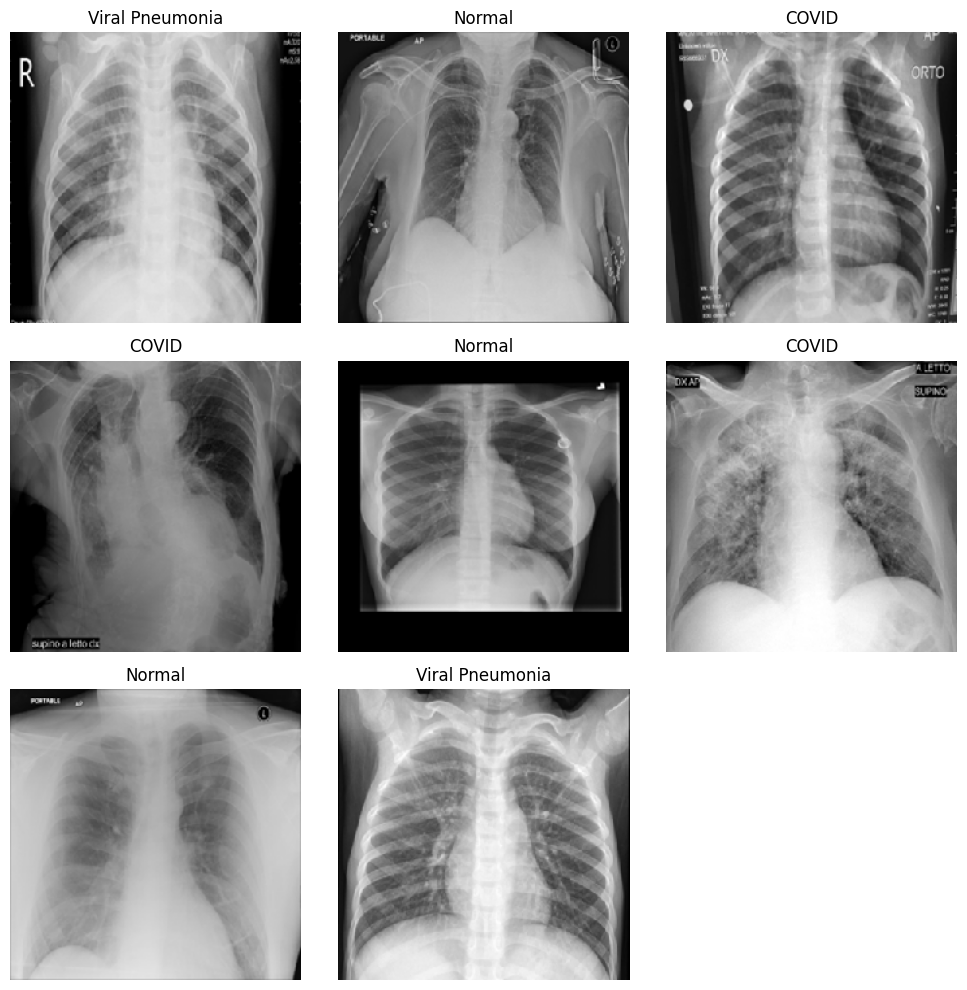

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels
images, labels = next(train_generator)

# Get class labels (index → class name)
class_names = list(train_generator.class_indices.keys())

# Plot images
plt.figure(figsize=(10, 10))

for i in range(len(images)):
    plt.subplot(3, 3, i+1)  # adjust grid size if needed
    plt.imshow(images[i])

    # Get label index
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])

    plt.axis('off')

plt.tight_layout()
plt.show()

**7. Model Building**

In [52]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(224, 224,3)) # Changed input shape to match generator
x = layers.Flatten()(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(64, activation='tanh')(x)
outputs = layers.Dense(3, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │     4,816,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,823,395 (18.40 MB)

 Trainable params: 4,823,395 (18.40 MB)

 Non-trainable params: 0 (0.00 B)

**8. Model Compilation and Training**

In [54]:
from tensorflow.keras.optimizers import Adam

adam = Adam(learning_rate=0.0001)
# We are going to use accuracy metrics and cross entropy loss as performance parameters
model.compile(adam, loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'accuracy'
# Train the model
history = model.fit(train_generator,
      steps_per_epoch=int(train_generator.samples / train_generator.batch_size),  # Convert to int
      epochs=100,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples / validation_generator.batch_size),  # Convert to int
      verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3167 - loss: 1.2692 - val_accuracy: 0.0000e+00 - val_loss: 1.2561
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3500 - loss: 1.0734 - val_accuracy: 0.1250 - val_loss: 1.1475
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5333 - loss: 1.0023 - val_accuracy: 0.3750 - val_loss: 1.1157
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6083 - loss: 0.9031 - val_accuracy: 0.3750 - val_loss: 1.0405
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6833 - loss: 0.8682 - val_accuracy: 0.6250 - val_loss: 0.9681
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7083 - loss: 0.8167 - val_accuracy: 0.7500 - val_loss: 0.9239
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7250 - loss: 0.7935 - val_accuracy: 0.7500 - val_loss: 0.8979
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7917 - loss: 0.7664 - val_accuracy

**9. Model saving**

In [55]:
model.save('covid_classification.h5')

**10. Model loading**

In [35]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [56]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [57]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

In [58]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

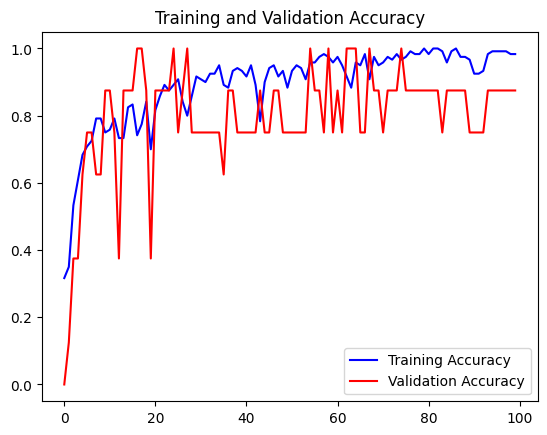

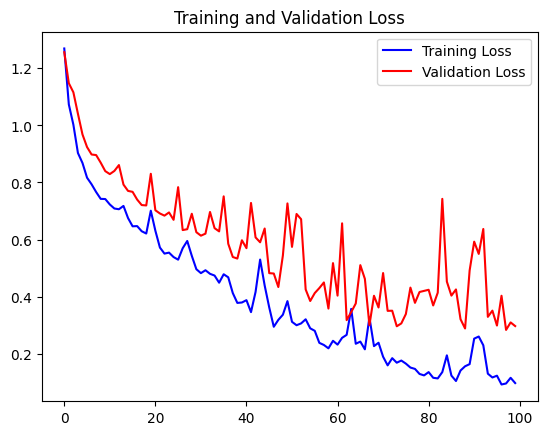

In [59]:
import matplotlib.pyplot as plt

epochs = range(len(train_acc))

# Accuracy Plot
plt.figure()
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  #

# Loss Plot
plt.figure()
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()  #

**14. Evaluate model performance on test dataset**

In [60]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5000 - loss: 1.3396
[1.3395599126815796, 0.5]
['loss', 'compile_metrics']


References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/